In [1]:
from pathlib import Path
import xarray as xr
import utils
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pacmap
from sklearn.datasets import load_digits

In [2]:
# The path for HAFS consolidated Date
folder_path = 'Model_Data/CompleteData'

# HAFS Data is in multiple NC files. Consolidate_Data creates one dataset
ds = utils.consolidate_data(folder_path)

# Checking for NA's
ds_cleaned = ds.dropna(dim = 'frame_number', how = 'any')

# Limiting frames to tropical storm strength or stronger (17 m/s or stronger)
ds_cleaned = ds_cleaned.where(ds_cleaned['max_wind'] >= 17, drop = True)

# Only using storms in the Northern Hemisphere
ds_cleaned = ds_cleaned.where(ds_cleaned['center_lat'] > 0, drop = True)

In [ ]:
ds_cleaned

In [3]:
# Normalizing data assuming gaussian distribution

normalized_data_gh_sfc = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 0))
normalized_data_t_sfc = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 0))
normalized_data_rh_sfc = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 0))
normalized_data_gh_700 = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 1))
normalized_data_t_700 = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 1))
normalized_data_rh_700 = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 1))
normalized_data_gh_200 = utils.standard_data_normalizer(ds_cleaned['gh'].isel(levels = 2))
normalized_data_t_200 = utils.standard_data_normalizer(ds_cleaned['t'].isel(levels = 2))
normalized_data_rh_200 = utils.standard_data_normalizer(ds_cleaned['rh'].isel(levels = 2))


In [4]:
# Constructing 700mb level datasets. Each array will be used in a UMAP reduction
# to test best combinations of data

combined_700 = np.stack((
                          normalized_data_gh_700, normalized_data_t_700, normalized_data_rh_700,
                          ), 
                          axis = 0).reshape(429, 3 * 720 * 501)
heights_700 = np.stack(normalized_data_gh_700,axis = 0).reshape(429, 1 * 720 * 501)
t_700 = np.stack(normalized_data_t_700,axis = 0).reshape(429, 1 * 720 * 501)
rh_700 = np.stack(normalized_data_rh_700,axis = 0).reshape(429, 1 * 720 * 501)


In [5]:
# Constructing surface level datasets. Each array will be used in a UMAP reduction
# to test best combinations of data

combined_sfc = np.stack((
                          normalized_data_gh_sfc, normalized_data_t_sfc, normalized_data_rh_sfc,
                          ), 
                          axis = 0).reshape(429, 3 * 720 * 501)
heights_sfc = np.stack(normalized_data_gh_sfc,axis = 0).reshape(429, 1 * 720 * 501)
t_sfc = np.stack(normalized_data_t_sfc,axis = 0).reshape(429, 1 * 720 * 501)
rh_sfc = np.stack(normalized_data_rh_sfc,axis = 0).reshape(429, 1 * 720 * 501)

In [ ]:
# Constructing a composite surface/700mb level dataset. Array contains surface 
# temperature data, and surface and 700mb geopotential heights. Met values were
# selected based on best results from the individual UMAP reductions.

combined_sfc700_gph_t = np.stack((
                          normalized_data_gh_sfc, normalized_data_gh_700, normalized_data_t_sfc,
                          ), 
                          axis = 0).reshape(429, 3 * 720 * 501)

In [6]:
# Creating the values to grade against. (Minimum Central Pressure and Maximum Surface Wind)

mslp = ds_cleaned['center_pressure'].values[:,0]
max_winds = ds_cleaned['max_wind'].values[:,0]

Creating Surface Level UMAP Reductions

In [7]:
reducer3 = pacmap.PaCMAP(n_components = 2, n_neighbors = 3, random_state = 42)
embedding_Fullsfc_n3 = reducer3.fit_transform(combined_sfc, init="pca")
embedding_GHsfc_n3 = reducer3.fit_transform(heights_sfc, init="pca")
embedding_Tsfc_n3 = reducer3.fit_transform(t_sfc, init="pca")
embedding_RHsfc_n3 = reducer3.fit_transform(rh_sfc, init="pca")

reducer5 = pacmap.PaCMAP(n_components = 2, n_neighbors = 5, random_state = 42)
embedding_Fullsfc_n5 = reducer5.fit_transform(combined_sfc, init="pca")
embedding_GHsfc_n5 = reducer5.fit_transform(heights_sfc, init="pca")
embedding_Tsfc_n5 = reducer5.fit_transform(t_sfc, init="pca")
embedding_RHsfc_n5 = reducer5.fit_transform(rh_sfc, init="pca")

reducer15 = pacmap.PaCMAP(n_components = 2, n_neighbors = 15, random_state = 42)
embedding_Fullsfc_n15 = reducer15.fit_transform(combined_sfc, init="pca")
embedding_GHsfc_n15 = reducer15.fit_transform(heights_sfc, init="pca")
embedding_Tsfc_n15 = reducer15.fit_transform(t_sfc, init="pca")
embedding_RHsfc_n15 = reducer15.fit_transform(rh_sfc, init="pca")

reducer10 = pacmap.PaCMAP(n_components = 2, n_neighbors = 10, random_state = 42)
embedding_Fullsfc_n10 = reducer10.fit_transform(combined_sfc, init="pca")
embedding_GHsfc_n10 = reducer10.fit_transform(heights_sfc, init="pca")
embedding_Tsfc_n10 = reducer10.fit_transform(t_sfc, init="pca")
embedding_RHsfc_n10 = reducer10.fit_transform(rh_sfc, init="pca")

reducer20 = pacmap.PaCMAP(n_components = 2, n_neighbors = 20, random_state = 42)
embedding_Fullsfc_n20 = reducer20.fit_transform(combined_sfc, init="pca")
embedding_GHsfc_n20 = reducer20.fit_transform(heights_sfc, init="pca")
embedding_Tsfc_n20 = reducer20.fit_transform(t_sfc, init="pca")
embedding_RHsfc_n20 = reducer20.fit_transform(rh_sfc, init="pca")


Creating 700mb Level UMAP Reductions

In [8]:
reducer3 = pacmap.PaCMAP(n_components = 2, n_neighbors = 3, random_state = 42)
embedding_Full700_n3 = reducer3.fit_transform(combined_700, init="pca")
embedding_GH700_n3 = reducer3.fit_transform(heights_700, init="pca")
embedding_T700_n3 = reducer3.fit_transform(t_700, init="pca")
embedding_RH700_n3 = reducer3.fit_transform(rh_700, init="pca")

reducer5 = pacmap.PaCMAP(n_components = 2, n_neighbors = 5, random_state = 42)
embedding_Full700_n5 = reducer5.fit_transform(combined_700, init="pca")
embedding_GH700_n5 = reducer5.fit_transform(heights_700, init="pca")
embedding_T700_n5 = reducer5.fit_transform(t_700, init="pca")
embedding_RH700_n5 = reducer5.fit_transform(rh_700, init="pca")

reducer15 = pacmap.PaCMAP(n_components = 2, n_neighbors = 15, random_state = 42)
embedding_Full700_n15 = reducer15.fit_transform(combined_700, init="pca")
embedding_GH700_n15 = reducer15.fit_transform(heights_700, init="pca")
embedding_T700_n15 = reducer15.fit_transform(t_700, init="pca")
embedding_RH700_n15 = reducer15.fit_transform(rh_700, init="pca")

reducer10 = pacmap.PaCMAP(n_components = 2, n_neighbors = 10, random_state = 42)
embedding_Full700_n10 = reducer10.fit_transform(combined_700, init="pca")
embedding_GH700_n10 = reducer10.fit_transform(heights_700, init="pca")
embedding_T700_n10 = reducer10.fit_transform(t_700, init="pca")
embedding_RH700_n10 = reducer10.fit_transform(rh_700, init="pca")

reducer20 = pacmap.PaCMAP(n_components = 2, n_neighbors = 20, random_state = 42)
embedding_Full700_n20 = reducer20.fit_transform(combined_700, init="pca")
embedding_GH700_n20 = reducer20.fit_transform(heights_700, init="pca")
embedding_T700_n20 = reducer20.fit_transform(t_700, init="pca")
embedding_RH700_n20 = reducer20.fit_transform(rh_700, init="pca")

Creating Composite UMAP Reductions

In [ ]:
reducer3 = pacmap.PaCMAP(n_components = 2, n_neighbors = 3, random_state = 42)
embedding_composite_n3 = reducer3.fit_transform(combined_sfc700_gph_t)

reducer5 = pacmap.PaCMAP(n_components = 2, n_neighbors = 5, random_state = 42)
embedding_composite_n5 = reducer5.fit_transform(combined_sfc700_gph_t)

reducer15 = pacmap.PaCMAP(n_components = 2, n_neighbors = 15, random_state = 42)
embedding_composite_n15 = reducer15.fit_transform(combined_sfc700_gph_t)

reducer10 = pacmap.PaCMAP(n_components = 2, n_neighbors = 10, random_state = 42)
embedding_composite_n10 = reducer10.fit_transform(combined_sfc700_gph_t)

reducer20 = pacmap.PaCMAP(n_components = 2, n_neighbors = 20, random_state = 42)
embedding_composite_n20 = reducer20.fit_transform(combined_sfc700_gph_t)


Plotting Surface Results

Text(0.5, 0.98, 'Comparison of PaCMAP reductions on HAFS Sfc GPH Model Output\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

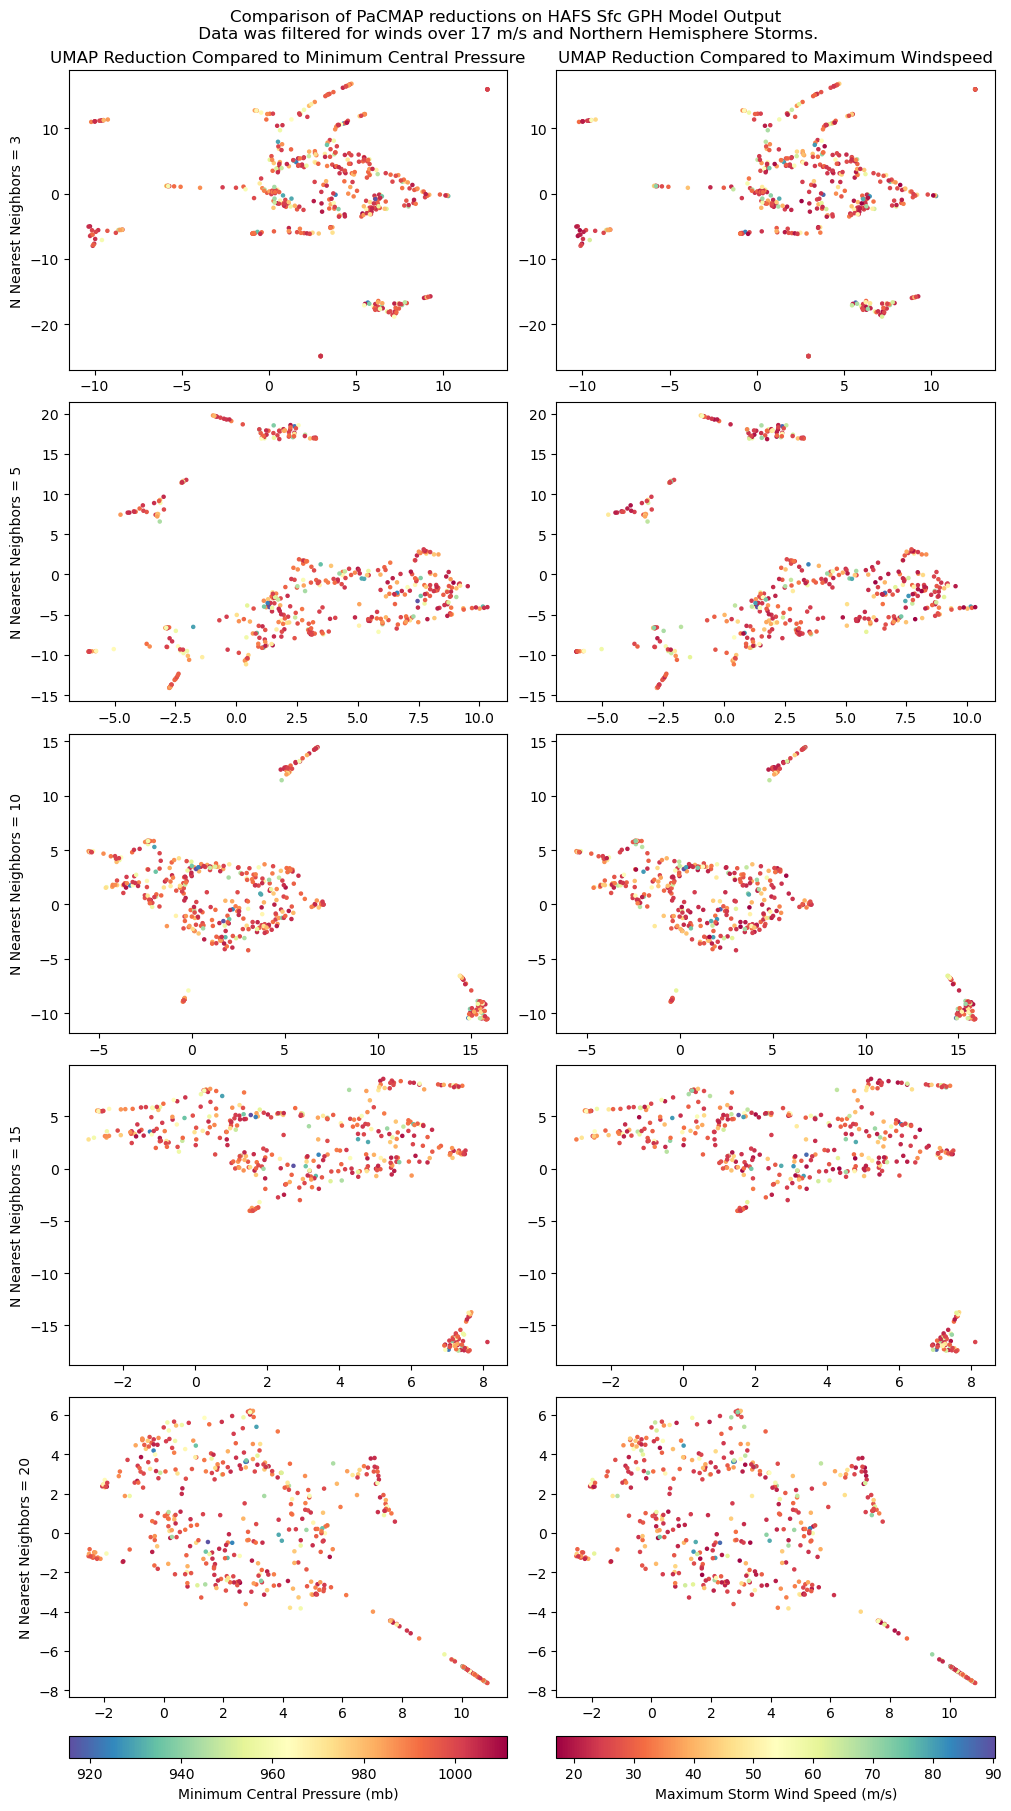

In [9]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, constrained_layout = True, figsize = (10,18))

ax[0,0].scatter(embedding_GHsfc_n3[:,0], embedding_GHsfc_n3[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[0,0].set_ylabel('N Nearest Neighbors = 3')
ax[0,0].set_title('UMAP Reduction Compared to Minimum Central Pressure')

ax[1,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[1,0].set_ylabel('N Nearest Neighbors = 5')

ax[2,0].scatter(embedding_GHsfc_n10[:,0], embedding_GHsfc_n10[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[2,0].set_ylabel('N Nearest Neighbors = 10')

ax[3,0].scatter(embedding_GHsfc_n15[:,0], embedding_GHsfc_n15[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[3,0].set_ylabel('N Nearest Neighbors = 15')

mslp_im = ax[4,0].scatter(embedding_GHsfc_n20[:,0], embedding_GHsfc_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[4,0], location = 'bottom', label = 'Minimum Central Pressure (mb)')

ax[0,1].scatter(embedding_GHsfc_n3[:,0], embedding_GHsfc_n3[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,1].set_title('UMAP Reduction Compared to Maximum Windspeed')

ax[1,1].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[2,1].scatter(embedding_GHsfc_n10[:,0], embedding_GHsfc_n10[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[3,1].scatter(embedding_GHsfc_n15[:,0], embedding_GHsfc_n15[:,1], c = max_winds, cmap = 'Spectral', s = 5)

max_wind_im = ax[4,1].scatter(embedding_GHsfc_n20[:,0], embedding_GHsfc_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[4,1], location = 'bottom', label = 'Maximum Storm Wind Speed (m/s)')

fig.suptitle('Comparison of PaCMAP reductions on HAFS Sfc GPH Model Output' \
            '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')


Plotting 700mb Results

Text(0.5, 0.98, 'Comparison of PaCMAP reductions on HAFS 700 GH Model Output\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

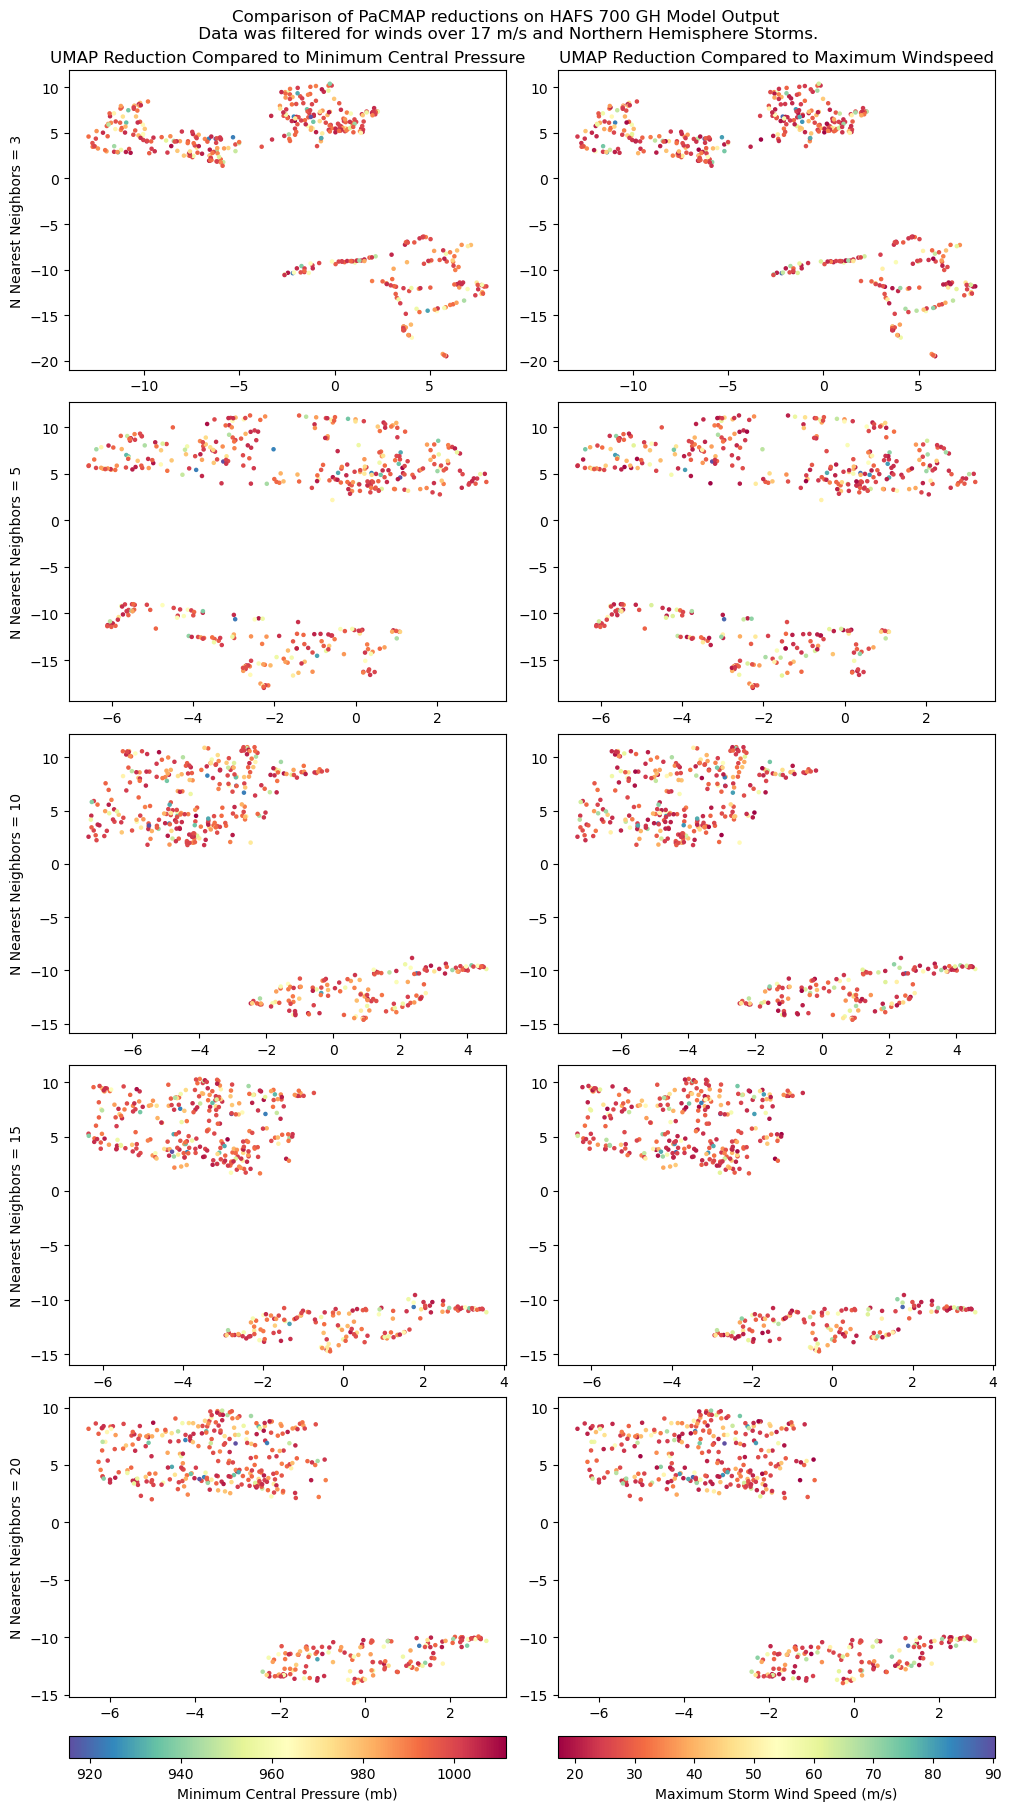

In [10]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, constrained_layout = True, figsize = (10,18))

ax[0,0].scatter(embedding_GH700_n3[:,0], embedding_GH700_n3[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[0,0].set_ylabel('N Nearest Neighbors = 3')
ax[0,0].set_title('UMAP Reduction Compared to Minimum Central Pressure')

ax[1,0].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[1,0].set_ylabel('N Nearest Neighbors = 5')

ax[2,0].scatter(embedding_GH700_n10[:,0], embedding_GH700_n10[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[2,0].set_ylabel('N Nearest Neighbors = 10')

ax[3,0].scatter(embedding_GH700_n15[:,0], embedding_GH700_n15[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[3,0].set_ylabel('N Nearest Neighbors = 15')

mslp_im = ax[4,0].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[4,0], location = 'bottom', label = 'Minimum Central Pressure (mb)')

ax[0,1].scatter(embedding_GH700_n3[:,0], embedding_GH700_n3[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,1].set_title('UMAP Reduction Compared to Maximum Windspeed')

ax[1,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[2,1].scatter(embedding_GH700_n10[:,0], embedding_GH700_n10[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[3,1].scatter(embedding_GH700_n15[:,0], embedding_GH700_n15[:,1], c = max_winds, cmap = 'Spectral', s = 5)

max_wind_im = ax[4,1].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[4,1], location = 'bottom', label = 'Maximum Storm Wind Speed (m/s)')

fig.suptitle('Comparison of PaCMAP reductions on HAFS 700 GH Model Output' \
            '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

Plotting Composite Results

In [ ]:
fig, ax = plt.subplots(nrows = 5, ncols = 2, constrained_layout = True, figsize = (10,18))

ax[0,0].scatter(embedding_composite_n3[:,0], embedding_composite_n3[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[0,0].set_ylabel('N Nearest Neighbors = 3')
ax[0,0].set_title('UMAP Reduction Compared to Minimum Central Pressure')

ax[1,0].scatter(embedding_composite_n5[:,0], embedding_composite_n5[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[1,0].set_ylabel('N Nearest Neighbors = 5')

ax[2,0].scatter(embedding_composite_n10[:,0], embedding_composite_n10[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[2,0].set_ylabel('N Nearest Neighbors = 10')

ax[3,0].scatter(embedding_composite_n15[:,0], embedding_composite_n15[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[3,0].set_ylabel('N Nearest Neighbors = 15')

mslp_im = ax[4,0].scatter(embedding_composite_n20[:,0], embedding_composite_n20[:,1], c = mslp, cmap = 'Spectral', s = 5)
ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[4,0], location = 'bottom', label = 'Minimum Central Pressure (mb)')

ax[0,1].scatter(embedding_composite_n3[:,0], embedding_composite_n3[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,1].set_title('UMAP Reduction Compared to Maximum Windspeed')

ax[1,1].scatter(embedding_composite_n5[:,0], embedding_composite_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[2,1].scatter(embedding_composite_n10[:,0], embedding_composite_n10[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[3,1].scatter(embedding_composite_n15[:,0], embedding_composite_n15[:,1], c = max_winds, cmap = 'Spectral', s = 5)

max_wind_im = ax[4,1].scatter(embedding_composite_n20[:,0], embedding_composite_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[4,1], location = 'bottom', label = 'Maximum Storm Wind Speed (m/s)')

fig.suptitle('Comparison of UMAP reductions on HAFS GPH at Sfc and 700 mb level, T at Sfc level Model Output' \
            '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')